In [79]:
import pandas as pd
import sqlite3

In [81]:
# CSV 데이터 불러와서 SQLite DB에 저장
df = pd.read_csv("Sample_ Superstore.csv ", encoding = "latin1")
conn = sqlite3.connect("superstore.db")
df.to_sql("Superstore", conn, index=False, if_exists="replace")

9994

In [82]:
# 컬럼명 확인
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [97]:
df.to_sql("Superstore", conn, index=False, if_exists="replace")

9994

In [98]:
# Order Date를 datetime 타입으로 변환 (형식이 섞여있어 format="mixed" 사용) 및 기간 확인
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
print(df["Order Date"].min())
print(df["Order Date"].max())

2014-01-03 00:00:00
2017-12-30 00:00:00


In [99]:
# SQL로 2017년(최근 1년) 데이터의 Region/Category/Sub-Category/Sales/Profit/Discount 추출
query = """
select Region, Category, "Sub-Category",
        Sales, Profit, Discount
from superstore
where "Order Date" >= '2017-01-01'
"""

result = pd.read_sql(query, conn)
result

,Region,Category,Sub-Category,Sales,Profit,Discount
0,South,Office Supplies,Paper,15.552,5.4432,0.2
1,East,Furniture,Chairs,71.372,-1.0196,0.3
2,Central,Office Supplies,Paper,29.472,9.9468,0.2
3,Central,Technology,Phones,147.168,16.5564,0.2
4,South,Office Supplies,Storage,95.616,9.5616,0.2
...,...,...,...,...,...,...
3307,South,Technology,Phones,206.100,55.6470,0.0
3308,West,Furniture,Furnishings,91.960,15.6332,0.0
3309,West,Technology,Phones,258.576,19.3932,0.2
3310,West,Office Supplies,Paper,29.600,13.3200,0.0


In [100]:
# 지역별 매출/이익/이익률 집계
region_sum = result.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

region_sum["Profit Margin"] = round(region_sum["Total_Profit"]/region_sum["Total_Sales"] * 100,2)
region_sum.sort_values("Profit Margin")

,Total_Sales,Total_Profit,Profit Margin
Region,,,
Central,147098.1282,7550.8442,5.13
South,122905.8575,8848.9079,7.20
East,213082.9040,33230.5614,15.60
West,250128.3655,43808.9561,17.51


C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


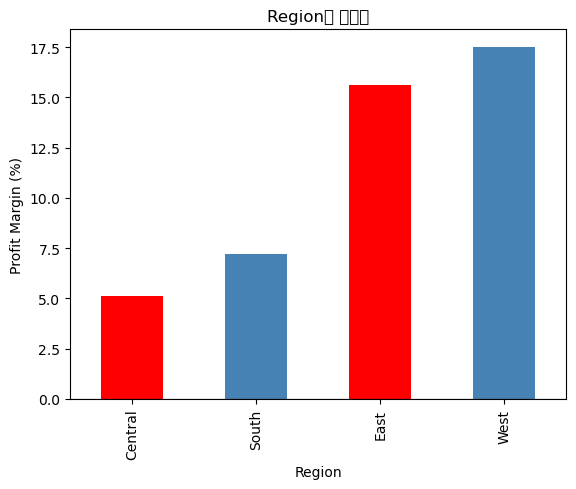

In [101]:
# 지역별 이익률 시각화 (Central/South 저조 구간 빨간색 강조)
import matplotlib.pyplot as plt

region_sum.sort_values("Profit Margin")["Profit Margin"].plot(kind="bar", color=["red" if x<10 else "steelblue" for x in region_sum["Profit Margin"]])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Profit Margin (%)")
plt.title("Region별 이익률")
plt.show()

In [102]:
# Central/South 지역의 카테고리별 매출/이익/이익률 집계
region_cat = result[result["Region"].isin(["Central", "South"])].groupby(["Region", "Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)
region_cat["Profit_Margin"] = round(region_cat["Total_Profit"] / region_cat["Total_Sales"] * 100, 2)
region_cat.sort_values(["Region", "Profit_Margin"])

Total_Sales  Total_Profit  Profit_Margin
Region  Category                                                 
Central Furniture         44522.2712    -1281.2808          -2.88
        Office Supplies   58770.5440       85.4777           0.15
        Technology        43805.3130     8746.6473          19.97
South   Furniture         38305.4255     -584.3960          -1.53
        Technology        44827.9200     3652.8888           8.15
        Office Supplies   39772.5120     5780.4151          14.53

In [103]:
# entral/South Furniture 카테고리의 서브카테고리별 매출/이익/이익률/평균할인율 집계
furniture_sub = result[(result["Region"].isin(["Central","South"])) & (result["Category"]=="Furniture")].groupby(["Region","Sub-Category"]).agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum"),
    Discount_avg = ("Discount", "mean")
)
furniture_sub["Profit_Margin"] = round(furniture_sub["Total_Profit"] / furniture_sub["Total_Sales"] * 100, 2)
furniture_sub["Discount_avg"] = furniture_sub["Discount_avg"].round(2) * 100
furniture_sub.sort_values(["Region","Profit_Margin"])

Total_Sales  Total_Profit  Discount_avg  Profit_Margin
Region  Sub-Category                                                        
Central Furnishings     5074.0220    -1319.6834          38.0         -26.01
        Tables         10589.3070    -2162.8466          29.0         -20.42
        Bookcases       5640.4772     -511.0254          26.0          -9.06
        Chairs         23218.4650     2712.2746          18.0          11.68
South   Tables         14106.2615    -3598.8946          27.0         -25.51
        Bookcases       5157.2660      514.4422          11.0           9.98
        Chairs         15656.3080     1931.0777          11.0          12.33
        Furnishings     3385.5900      568.9787          13.0          16.81

C:\Users\user\AppData\Local\Temp\ipykernel_16284\1644318608.py:15: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\1644318608.py:15: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\1644318608.py:15: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\1644318608.py:15: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\1644318608.py:15: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\1644318608.py:15: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) 

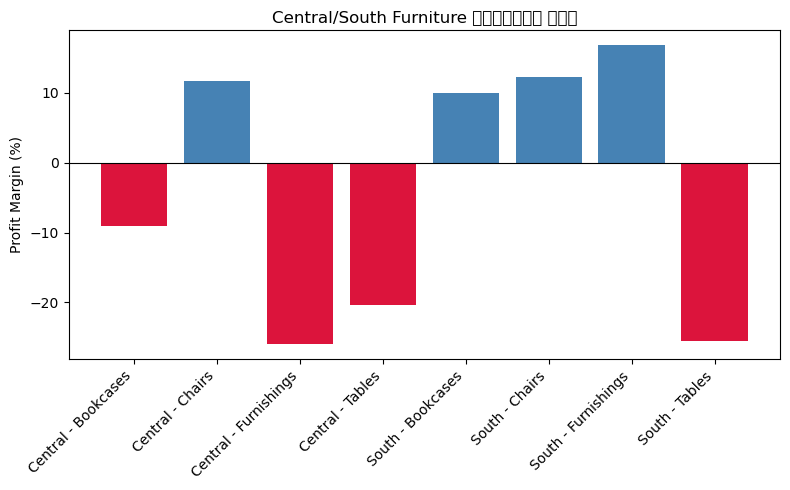

In [104]:
# Furniture 서브카테고리별 이익률 시각화 (마이너스 구간 빨간색 강조)
import matplotlib.pyplot as plt

furniture_plot = furniture_sub.reset_index()
furniture_plot["Label"] = furniture_plot["Region"] + " - " + furniture_plot["Sub-Category"]

colors = ["crimson" if x < 0 else "steelblue" for x in furniture_plot["Profit_Margin"]]

plt.figure(figsize=(8, 5))
plt.bar(furniture_plot["Label"], furniture_plot["Profit_Margin"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Profit Margin (%)")
plt.title("Central/South Furniture 서브카테고리별 이익률")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [105]:
# Central Office Supplies 카테고리의 서브카테고리별 매출/이익/이익률/평균할인율 집계
Office_sub = result[(result["Region"] == "Central") & (result["Category"] == "Office Supplies")].groupby(["Region","Sub-Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Discount_avg = ("Discount", "mean")
)

Office_sub["Profit Margin"] = round(Office_sub["Total_Profit"]/Office_sub["Total_Sales"] * 100, 2)
Office_sub["Discount_avg"] = Office_sub["Discount_avg"].round(2) * 100
Office_sub.sort_values("Profit Margin")

Total_Sales  Total_Profit  Discount_avg  Profit Margin
Region  Sub-Category                                                        
Central Binders         21105.376    -3957.1425          48.0         -18.75
        Appliances       8933.308     -313.3837          47.0          -3.51
        Supplies         4407.560      117.7200          13.0           2.67
        Storage         13693.740      409.0049          12.0           2.99
        Art              2291.276      497.8317          14.0          21.73
        Fasteners         320.230      112.2314          11.0          35.05
        Paper            6235.280     2471.5800          13.0          39.64
        Envelopes        1196.532      487.8046          11.0          40.77
        Labels            587.242      259.8313          10.0          44.25

In [106]:
# 가설 검정 - 할인율이 높을수록 이익률이 낮다 / 전체 데이터 기준 할인율별 이익률 집계

discount_result = result.groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

discount_result["Profit Margin"] = round(discount_result["Total_Profit"]/discount_result["Total_Sales"] * 100, 2)
discount_result.sort_values("Discount")

,Total_Sales,Total_Profit,Profit Margin
Discount,,,
0.00,348818.1500,104157.7122,29.86
0.10,18957.3480,3300.5929,17.41
0.15,8762.7945,537.5329,6.13
0.20,249314.9680,33013.3314,13.24
0.30,31306.8980,-3867.6022,-12.35
0.32,3717.1112,-492.2300,-13.24
0.40,34100.0520,-7833.1461,-22.97
0.45,2509.6115,-1228.4406,-48.95
0.50,13801.4450,-6864.3883,-49.74


C:\Users\user\AppData\Local\Temp\ipykernel_16284\3829462080.py:10: UserWarning: Glyph 54624 (\N{HANGUL SYLLABLE HAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\3829462080.py:10: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\3829462080.py:10: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\3829462080.py:10: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\3829462080.py:10: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16284\3829462080.py:10: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s

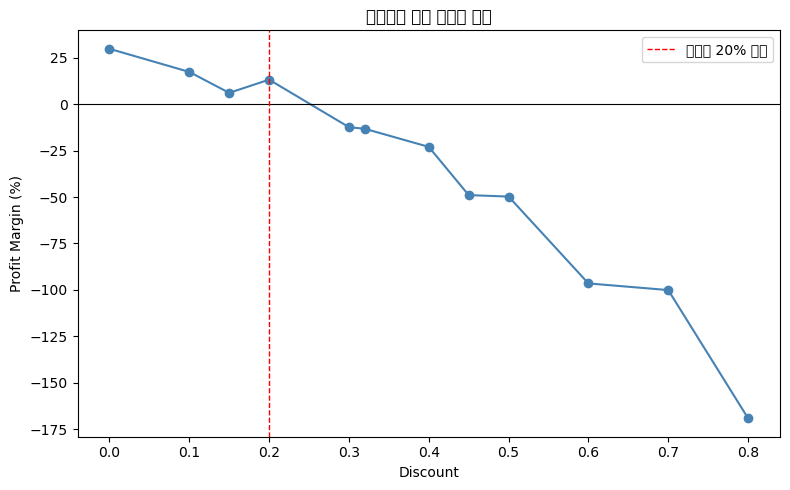

In [107]:
# 할인율 vs 이익률 관계 시각화 (20% 지점에 기준선 표시)
plt.figure(figsize=(8, 5))
plt.plot(discount_result.index, discount_result["Profit Margin"], marker="o", color="steelblue")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0.2, color="red", linestyle="--", linewidth=1, label="할인율 20% 지점")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.title("할인율에 따른 이익률 변화")
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
# 전체 데이터의 할인율, 이익율의 상관관계 계산
discount_result.index.to_series().corr(discount_result["Profit Margin"])

np.float64(-0.9621177690569384)

In [108]:
# 가설 검증 - 분석 대상 8개 지역x서브카테고리 조합의 매출/이익/이익률/평균할인율 재집계
targets = [
    ("Central", "Furnishings"), ("Central", "Tables"), ("Central", "Bookcases"),
    ("Central", "Binders"), ("Central", "Appliances"), ("Central", "Supplies"), ("Central", "Storage"),
    ("South", "Tables")
]

mask = result.apply(lambda row: (row["Region"], row["Sub-Category"]) in targets, axis=1)

check = result[mask].groupby(["Region", "Sub-Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean")
)
check["Profit_Margin"] = round(check["Total_Profit"] / check["Total_Sales"] * 100, 2)
check.sort_values("Profit_Margin")

Total_Sales  Total_Profit  Avg_Discount  Profit_Margin
Region  Sub-Category                                                        
Central Furnishings     5074.0220    -1319.6834      0.383607         -26.01
South   Tables         14106.2615    -3598.8946      0.270588         -25.51
Central Tables         10589.3070    -2162.8466      0.292308         -20.42
        Binders        21105.3760    -3957.1425      0.484848         -18.75
        Bookcases       5640.4772     -511.0254      0.257500          -9.06
        Appliances      8933.3080     -313.3837      0.471739          -3.51
        Supplies        4407.5600      117.7200      0.128571           2.67
        Storage        13693.7400      409.0049      0.123288           2.99

In [113]:
# 할인율과 이익률의 상관계수 계산 (가설 최종 검증) 표본 데이터 적음
check["Avg_Discount"].corr(check["Profit_Margin"])

np.float64(-0.4959486044823189)